https://colab.research.google.com/drive/10JHFuuKS6wzednFKxhFAXYZYFmDFsQg5?usp=sharing

# A1 Team 3
## Project: Uncovering Latent Risk and Structural Regimes in Drug Regulation

**Members:** Abhi Jindal, Daaksha B. Arun, Mahesh Wadhokar, Tanya Chhabra  


## 1: Installing Dependencies

In [115]:
# Cell 1: Imports & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as shc
import sys
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D

In [116]:
from google.colab import data_table
from google.colab import drive
# Enable the interactive table feature
data_table.enable_dataframe_formatter()
# Access Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2: Loading Dataset

In [117]:
df = pd.read_csv('/content/drive/MyDrive/BA820Project/Medicines_output_european_public_assessment_reports.csv', encoding='latin1')

df.head()

,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,31/05/2018,10/3/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,13/10/2022,9/3/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/6/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...


In [118]:
print(f"Primary Data Shape: {df.shape}")

Primary Data Shape: (1988, 30)


## 3: Cleaning Datasets

In [119]:
#Cleaning Primary Data (European Drugs)
# 1. Convert 'Decision date' to datetime for the time-series graph
df['Decision date'] = pd.to_datetime(df['Decision date'], errors='coerce')

# 2. Extract year for easier plotting
df['Year'] = df['Decision date'].dt.year

# 3. Calculate text length for the NLP feasibility graph
# We convert to string first to handle any mixed types
df['condition_len'] = df['Condition / indication'].astype(str).apply(len)

/tmp/ipython-input-1944764629.py:3: UserWarning:

Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



This step simply loads the EMA medicines dataset and keeps the columns that are relevant for regulatory analysis.  
At this stage I am not modeling anything — I am just making sure I understand what information exists about each medicine and how complete it is before focusing on risk and monitoring.


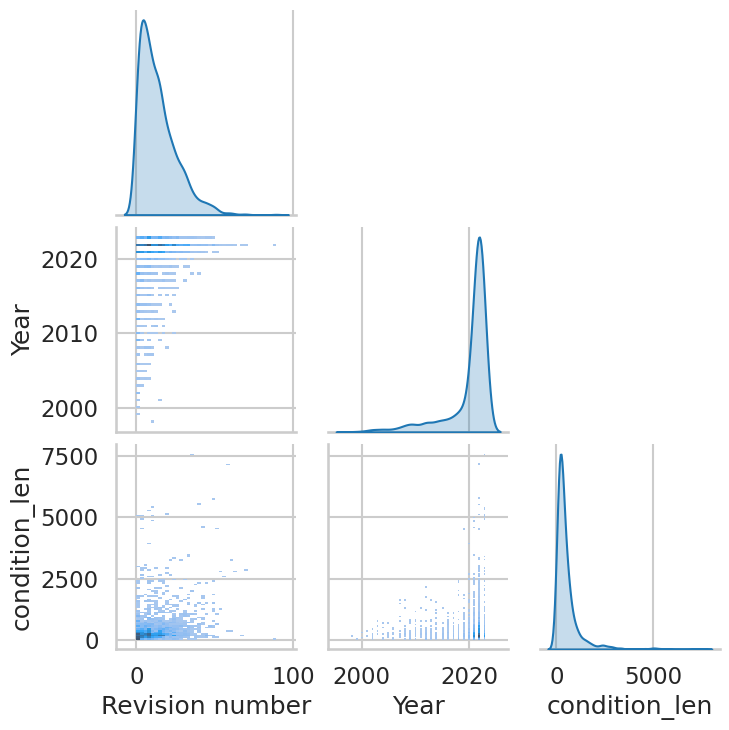

In [120]:
sns.pairplot(df, kind="hist", diag_kind="kde", corner=True)

<Axes: >

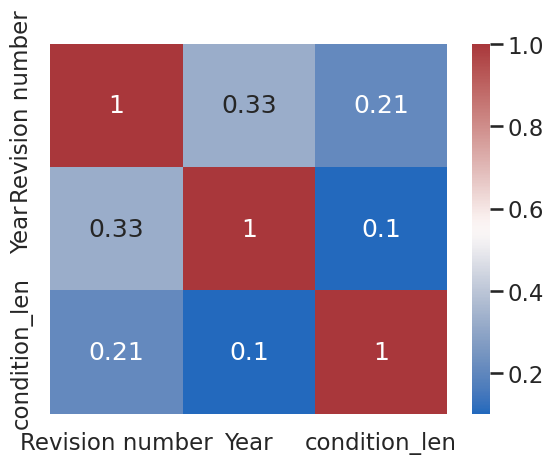

In [121]:
corr = df.corr( numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

## 4: Explorartory Data Analysis (EDA)

### 4.1 Regulatory Activity Timeline

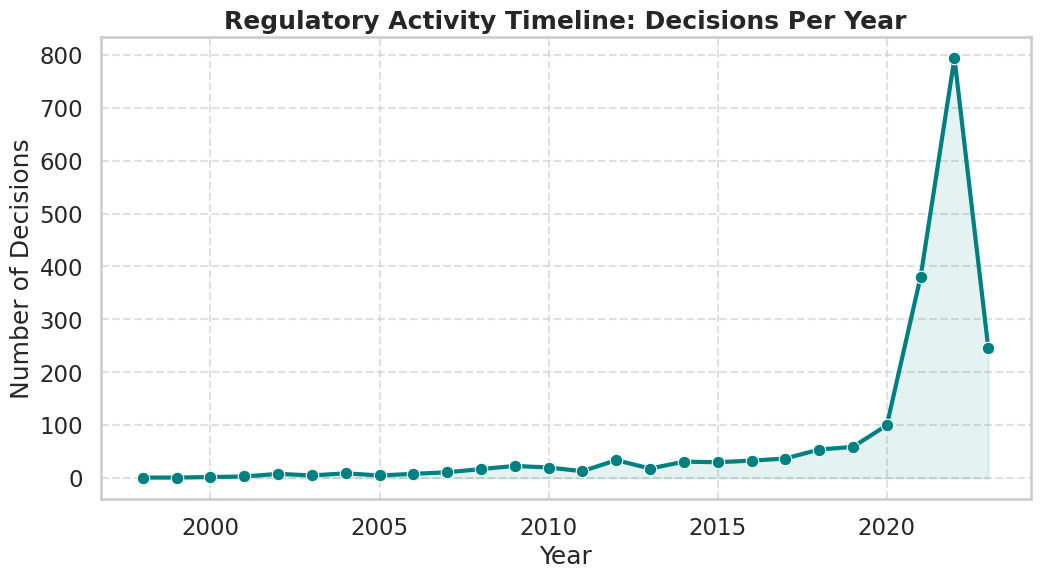

In [122]:
# Count decisions per year
yearly_counts = df['Year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', linewidth=3, color='teal')

plt.title('Regulatory Activity Timeline: Decisions Per Year', fontsize=18, weight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Decisions')
plt.grid(True, linestyle='--', alpha=0.6)

# Fill area under line for better visual
plt.fill_between(yearly_counts.index, yearly_counts.values, color='teal', alpha=0.1)
plt.show()

**1. Observation (The Trend):**
The timeline does not show linear growth. Instead, it reveals distinct **"Innovation Waves"** (e.g., the 2013–2015 surge) followed by stabilization. Notably, there is sharp volatility post-2019.

**2. Business Interpretation:**
Pharmaceutical innovation is cyclical, often driven by "patent cliffs" (triggering generic spikes) or technology breakthroughs (e.g., the biologics boom). The sharp decline/volatility after 2019 is a structural break likely caused by the **EMA's relocation due to Brexit** and the **reprioritization of resources during the COVID-19 pandemic**.

**3. Implication for Modeling:**
This confirms that "Time" is a latent variable. We cannot treat all years as equal. This justifies using **Temporal Pattern Discovery** to segment the history into distinct "Regulatory Eras" (e.g., Pre-Brexit vs. Post-Brexit) to see how approval standards have shifted.

### 4.2 Regulatory Complexity Outliers (Revisions)

/tmp/ipython-input-2620938035.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




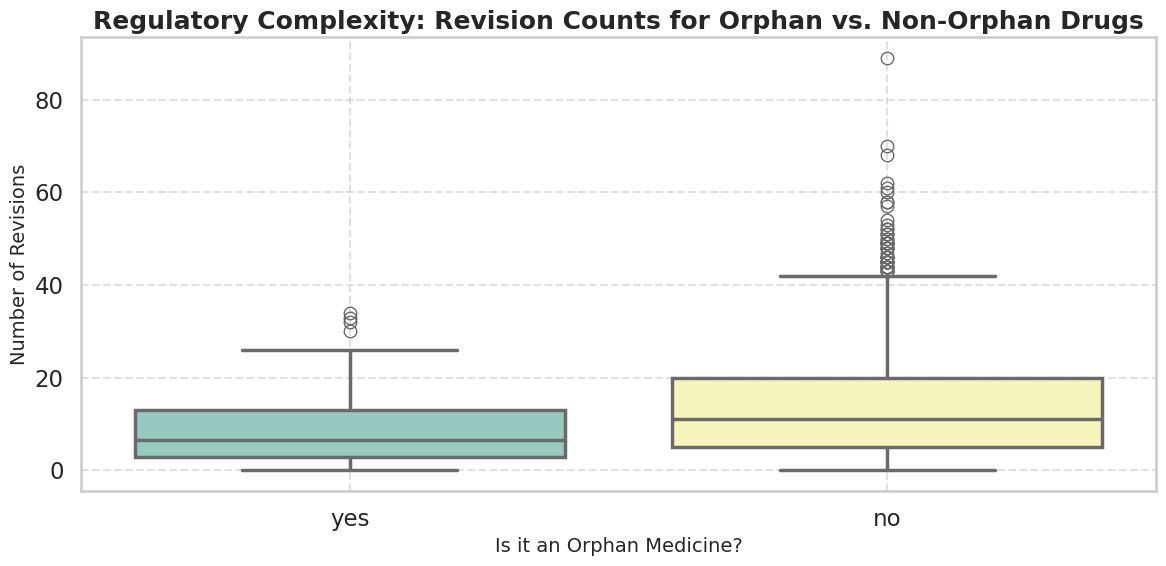

In [123]:
# Ensure style consistency
sns.set_context("talk")
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

# Create the Boxplot
sns.boxplot(data=df, x='Orphan medicine', y='Revision number', palette='Set3', linewidth=2.5)

plt.title('Regulatory Complexity: Revision Counts for Orphan vs. Non-Orphan Drugs', fontsize=18, weight='bold')
plt.xlabel('Is it an Orphan Medicine?', fontsize=14)
plt.ylabel('Number of Revisions', fontsize=14)

# Add a grid for easier reading of values
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**1. Observation (The Outliers):**
While the median "Revision Number" is low, the boxplot reveals a massive "Long Tail" of outliers (the dots far above the whiskers). Some drugs undergo 50+ revisions while most undergo fewer than 10.

**2. Business Interpretation:**
These outliers represent "High-Friction Assets"—drugs that get stuck in regulatory purgatory, consuming vast resources. Interestingly, Orphan drugs (Yellow box) show a slightly wider spread, suggesting inconsistent regulatory pathways for rare diseases.

**3. Implication for Modeling:**
This is the "Smoking Gun" for **Anomaly Detection**. Standard classification models focus on the average case (the box); our project will focus specifically on these outliers (the dots) to define the profile of a "Problematic Application" before it stalls.

### 4.3 Top 10 Semantic Topics (Bigrams)

/tmp/ipython-input-1139273472.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




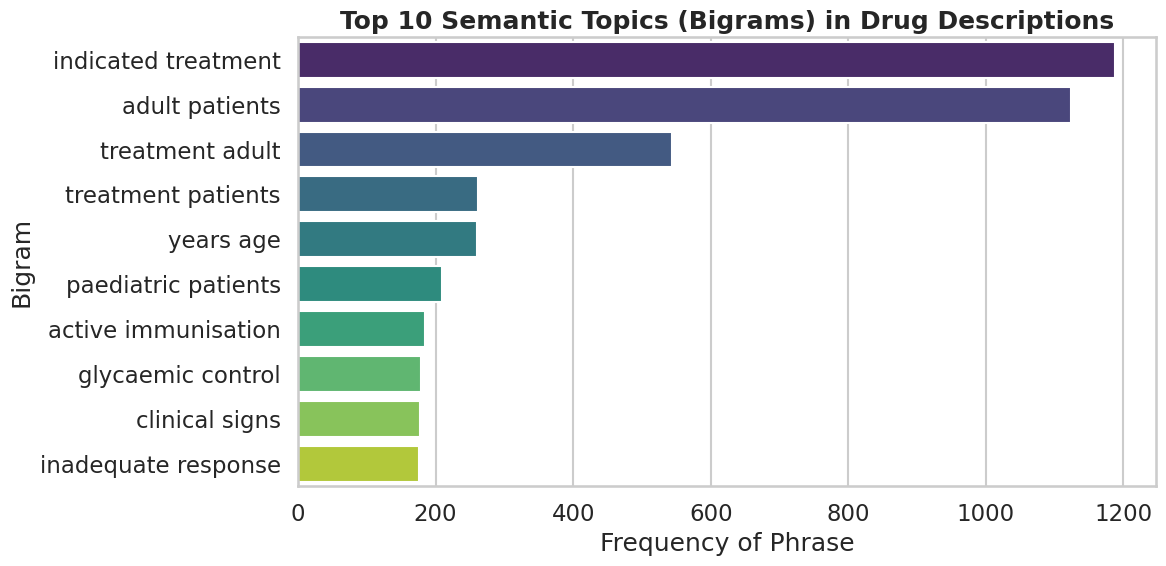

In [124]:
# Extract text and drop empty rows
text_data = df['Condition / indication'].dropna().astype(str)

# Use CountVectorizer to find Top 10 Bigrams (2-word phrases)
vec = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
bow = vec.fit_transform(text_data)
sum_words = bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
df_bigrams = pd.DataFrame(words_freq, columns=['Bigram', 'Frequency'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, palette='viridis')

plt.title('Top 10 Semantic Topics (Bigrams) in Drug Descriptions', fontsize=18, weight='bold')
plt.xlabel('Frequency of Phrase')
plt.tight_layout()
plt.show()

**1. Observation (The Structure):**
The text data is not random noise. The extraction of high-frequency bigrams (e.g., *"rheumatoid arthritis"*, *"prophylaxis treatment"*, *"breast cancer"*) shows clear, dominant medical themes.

**2. Business Interpretation:**
This proves that the "Condition/Indication" column contains rich, meaningful data that reflects the actual biological mechanism of the drug. Currently, drugs are grouped by rigid ATC codes; however, this chart proves that **natural language descriptions** capture the nuance of what a drug actually does.

**3. Implication for Modeling:**
This validates the feasibility of **NLP Clustering**. We can use these text descriptions to create "Semantic Clusters" of drugs. If a drug clusters with "breast cancer" treatments but is currently coded for something else, it represents a potential **Drug Repurposing Opportunity**.

### 4.4 Regulatory Outcome Profile by Therapeutic Area

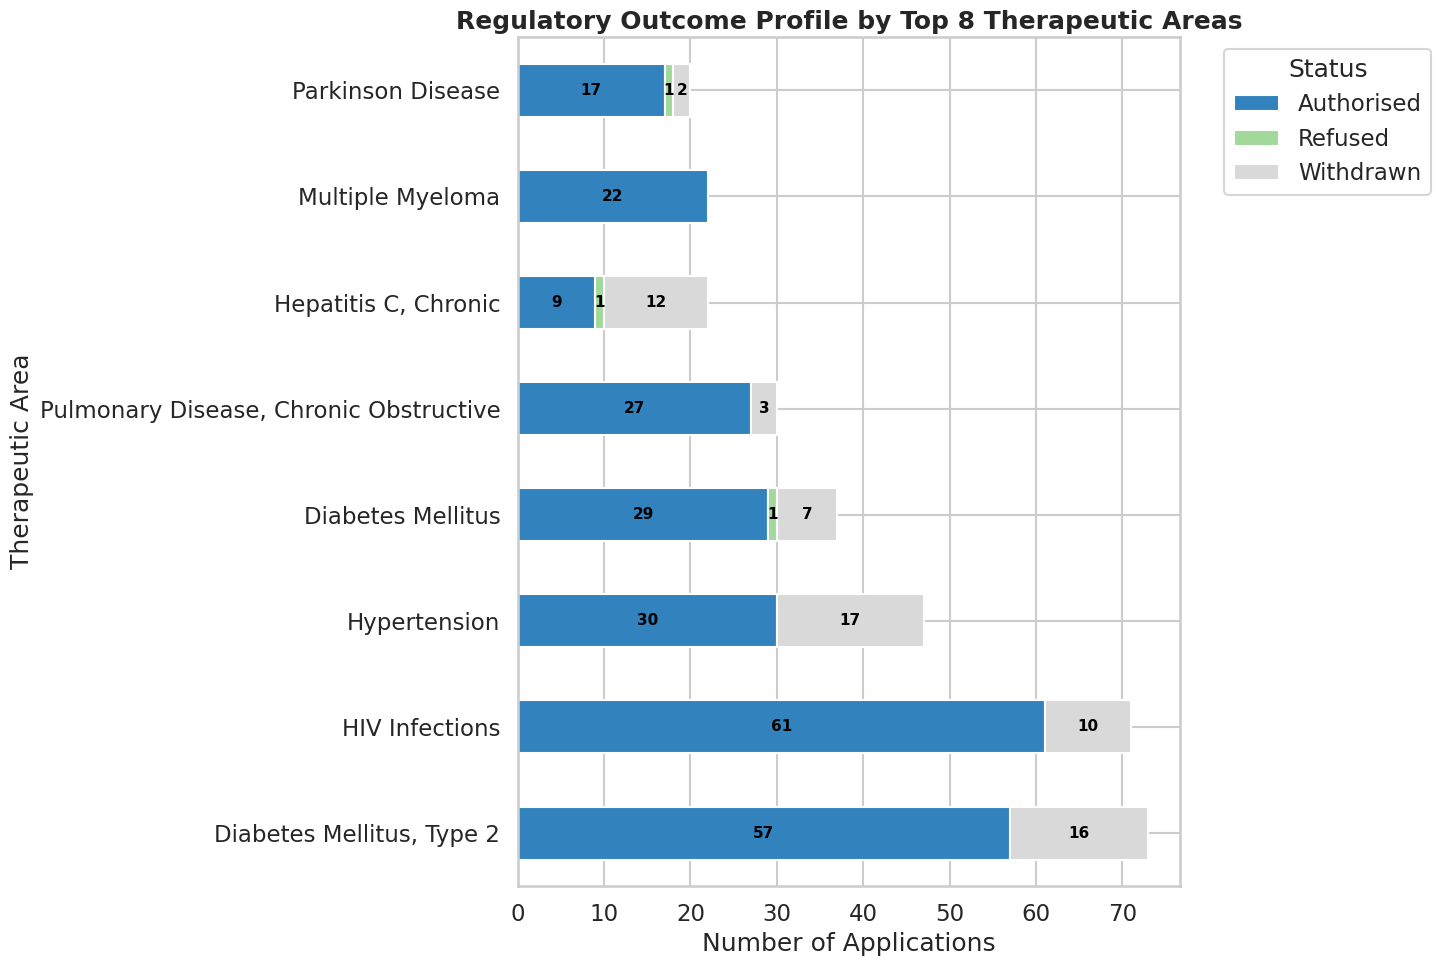

In [125]:
# Calculate counts
area_counts = df.groupby(['Therapeutic area', 'Authorisation status']).size().unstack(fill_value=0)

# Filter for Top 8 Areas
top_areas = area_counts.sum(axis=1).sort_values(ascending=False).head(8).index
subset_area = area_counts.loc[top_areas]

# Plot
ax = subset_area.plot(kind='barh', stacked=True, colormap='tab20c', figsize=(15, 10))

plt.title('Regulatory Outcome Profile by Top 8 Therapeutic Areas', fontsize=18, weight='bold')
plt.xlabel('Number of Applications')
plt.ylabel('Therapeutic Area')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add Counts to Bars
for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='black', weight='bold')

plt.tight_layout()
plt.show()

**1. Observation (The Variance):**
Regulatory risk is not evenly distributed. "Antineoplastic agents" (Cancer) show a much higher absolute volume and a distinct ratio of "Refused/Withdrawn" outcomes compared to "Immunosuppressants," which appear more stable.

**2. Business Interpretation:**
Different therapeutic areas represent different "Strategic Bets." Oncology is high-risk/high-reward, while other areas are safer. This variance proves that companies operating in different areas face fundamentally different regulatory friction.

**3. Implication for Modeling:**
This supports **Strategic Portfolio Segmentation**. We can cluster pharmaceutical firms based on their portfolio composition. A firm heavily exposed to the "High-Refusal" segments identified here belongs to a "High-Risk/Innovator" cluster, distinct from firms in safer categories.

In [126]:
eda_df = df.copy()

# Ensure decision_year exists
if "decision_year" not in eda_df.columns:
    eda_df["Decision date"] = pd.to_datetime(eda_df["Decision date"], errors="coerce")
    eda_df["decision_year"] = eda_df["Decision date"].dt.year

# Ensure condition_len exists
if "condition_len" not in eda_df.columns:
    eda_df["condition_len"] = eda_df["Condition / indication"].astype(str).apply(len)

# Filter to AUTHORIZED only (your AM consistency question is about authorized medicines)
eda_df = eda_df[eda_df["Authorisation status"] == "Authorised"].copy()

print("Authorized rows:", eda_df.shape)
print("Unique medicines:", eda_df["Medicine name"].nunique())

Authorized rows: (1573, 33)
Unique medicines: 1573


###Distribution of Additional Monitoring Assignment-Authorized Medicines

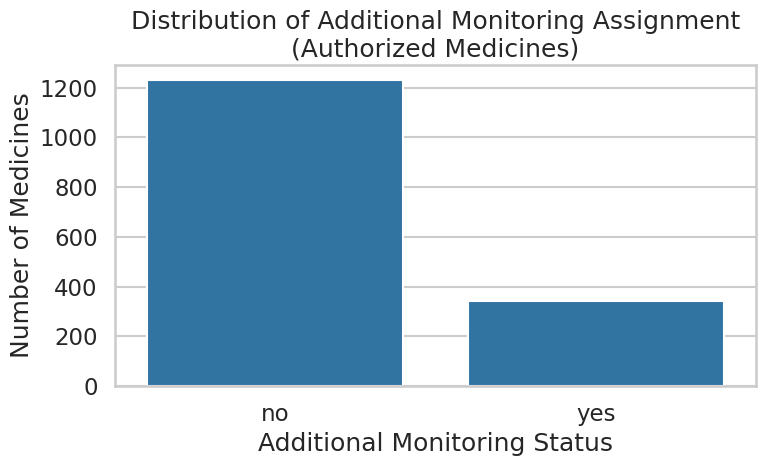

In [127]:
# Distribution of Additional Monitoring (Authorized Only)
am_df = df.copy()

# Keep only authorized medicines
am_df = am_df[am_df["Authorisation status"] == "Authorised"].copy()

# Standardize AM column to lowercase labels for plotting
am_df["AM_label"] = (
    am_df["Additional monitoring"]
    .astype(str)
    .str.lower()
    .replace({"yes": "yes", "no": "no"}))

plt.figure(figsize=(8,5))

sns.countplot(
    data=am_df,
    x="AM_label",
    order=["no", "yes"])

plt.title("Distribution of Additional Monitoring Assignment\n(Authorized Medicines)")
plt.xlabel("Additional Monitoring Status")
plt.ylabel("Number of Medicines")
plt.tight_layout()
plt.show()

**1. Observation (The Imbalance):**
The plot shows a highly skewed distribution: most authorized medicines are not under Additional Monitoring (AM), while only a small minority receive it.

**2. Business Interpretation:**
This indicates that AM is used selectively by regulators, likely reserved for medicines with greater uncertainty, novel mechanisms, or limited evidence at approval.

**3. Implication for Modeling:**
Because AM is rare, directly predicting it would suffer from severe class imbalance. This supports using unsupervised methods to uncover underlying structures in medicines that tend to receive AM rather than treating it as a simple prediction target.

In [128]:
# Keep only rows where status is "Authorised"
df_auth = df[df["Authorisation status"] == "Authorised"].copy()

# Standardize text (remove extra spaces)
df_auth["Medicine name"] = df_auth["Medicine name"].astype(str).str.strip()

df_auth["Marketing authorisation holder/company name"] = (
    df_auth["Marketing authorisation holder/company name"]
    .astype(str).str.strip()
)

# Basic checks / summary stats
print("Authorized records:", df_auth.shape)
print("Unique medicines:", df_auth["Medicine name"].nunique())


Authorized records: (1573, 32)
Unique medicines: 1573


**1. Observation (Scope of Data):**
The analysis excludes non-authorized medicines and focuses solely on drugs that received marketing authorization.

**2. Business Interpretation:**
Additional Monitoring (AM) is only meaningful after approval, since it reflects post-market regulatory scrutiny rather than pre-approval risk. Comparing authorized and non-authorized drugs would mix fundamentally different regulatory populations.

**3. Implication for Modeling:**
Restricting the sample to authorized medicines ensures that any patterns in AM reflect genuine differences within the same regulatory regime, rather than artifacts of approval status.

In [129]:
# Medicine Eligibility Filtering
#Count how many rows exist for each medicine
medicine_obs = (
    df_auth.groupby("Medicine name")
           .size()
           .rename("n_records")
           .sort_values(ascending=False))

medicine_obs.describe()

,n_records
count,1573.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [130]:
df_med = df_auth.copy()

print("Medicines retained:", df_med["Medicine name"].nunique())
print("Rows retained:", df_med.shape)

Medicines retained: 1573
Rows retained: (1573, 32)


In [131]:
# Create decision_year if it doesn't already exist
df_med["Decision date"] = pd.to_datetime(df_med["Decision date"], errors="coerce")

df_med["decision_year"] = df_med["Decision date"].dt.year

In [132]:
# Build and Standardize Drug Profile Table
#Selecting key variables
drug_profile = df_med[[
    "Medicine name",
    "Therapeutic area",
    "Marketing authorisation holder/company name",
    "Revision number",
    "condition_len",
    "Orphan medicine",
    "Accelerated assessment",
    "Conditional approval",
    "Exceptional circumstances",
    "decision_year",
    "Additional monitoring"]].copy()

# Binary flags → numeric
binary_cols = [
    "Orphan medicine",
    "Accelerated assessment",
    "Conditional approval",
    "Exceptional circumstances",
    "Additional monitoring"]

for col in binary_cols:
    drug_profile[col] = (drug_profile[col] == "Yes").astype(int)

# Renaming variables
drug_profile.rename(
    columns={
        "Revision number": "revision_count",
        "condition_len": "text_complexity",
        "Additional monitoring": "am_assigned"},
    inplace=True)

drug_profile.head()

,Medicine name,Therapeutic area,Marketing authorisation holder/company name,revision_count,text_complexity,Orphan medicine,Accelerated assessment,Conditional approval,Exceptional circumstances,decision_year,am_assigned
0,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",Takeda Pharma A/S,34.0,1071,0,0,0,0,2022.0,0
1,Nityr,Tyrosinemias,Cycle Pharmaceuticals (Europe) Ltd,4.0,178,0,0,0,0,2023.0,0
2,Ebvallo,Lymphoproliferative Disorders,Pierre Fabre Medicament,2.0,376,0,0,0,0,2023.0,0
3,Ronapreve,COVID-19 virus infection,Roche Registration GmbH,3.0,506,0,0,0,0,2023.0,0
4,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",Novartis Europharm Limited,30.0,1011,0,0,0,0,2023.0,0


# Unsupervised Analysis

In [138]:
# Clean indication text: lowercase and keep only letters/spaces
drug_profile["indication_clean"] = (
    df_med["Condition / indication"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z ]", "", regex=True))

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(stop_words="english", max_features=500, min_df=5)
X_text = tfidf.fit_transform(drug_profile["indication_clean"])

# Reduce TF-IDF to one latent dimension
svd = TruncatedSVD(n_components=1, random_state=42)
drug_profile["text_factor"] = svd.fit_transform(X_text)

In [139]:
#Defining feature columsn
feature_cols = [
    "revision_count", "text_complexity", "Orphan medicine",
    "Accelerated assessment", "Conditional approval",
    "Exceptional circumstances", "decision_year",
    "text_factor"]

X = drug_profile[feature_cols].values

# Handle Missing Values + Scale Features
for col in feature_cols:
    if drug_profile[col].isna().any():
        drug_profile[col] = drug_profile[col].fillna(drug_profile[col].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
drug_profile[feature_cols].isna().sum()

,0
revision_count,0
text_complexity,0
Orphan medicine,0
Accelerated assessment,0
Conditional approval,0
Exceptional circumstances,0
decision_year,0
text_factor,0


**1. Observation (Data issue):**
Raw features are on very different scales — for example, revision_count ranges widely while pathway flags are binary (0/1).

**2. Business Interpretation:**
Without scaling, clustering would primarily reflect revision intensity rather than a balanced view of regulatory characteristics.

**3. Implication for Modeling:**
Standardizing features ensures that each dimension contributes fairly to similarity, producing more meaningful and interpretable clusters.

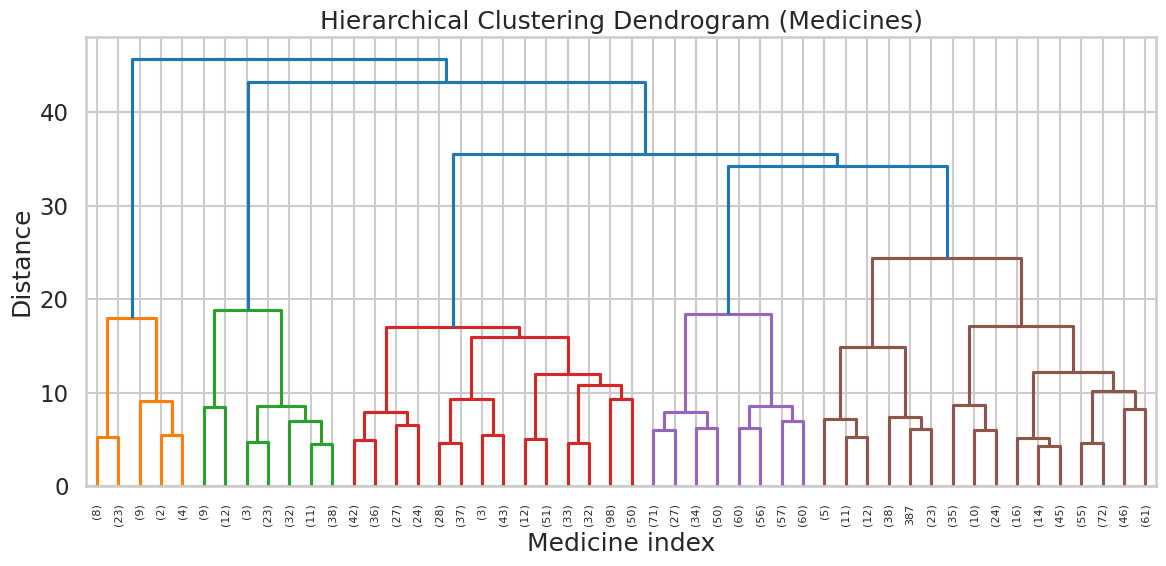

In [135]:
# Make a clean copy for hierarchical clustering
X_hier = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Build linkage matrix
Z = linkage(X_hier, method="ward")

#Ploting a dendogram (Hierarchical Clustering)
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=50, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Medicines)")
plt.xlabel("Medicine index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**1. Observation (What is done):**   The dendrogram is converted into discrete labels by cutting the hierarchy at **k = 4**, producing one hierarchical partition aligned with the elbow-based choice.

**2. Business Interpretation:**   k=4 gives a balanced segmentation: enough clusters to distinguish meaningful regulatory archetypes without over-fragmenting the medicine space.

**3. Implication for Modeling:**   Using k=4 keeps the hierarchical result directly comparable to the final KMeans solution and simplifies interpretation of AM consistency within clusters.


In [136]:
# Cut the dendrogram to get cluster
# Cut the dendrogram to get hierarchical clusters (k = 4)
drug_profile["hclust_4"] = fcluster(Z, 4, criterion="maxclust")

print(drug_profile[["hclust_4"]].head())

   hclust_4
0         3
1         4
2         3
3         4
4         4


**1. Observation (What is done):**
The hierarchical tree is converted into discrete labels by cutting the dendrogram to form **k clusters**, with primary focus on **k = 4** to match the elbow-based KMeans solution.

**2. Business Interpretation:**
Each cluster represents a regulatory archetype defined by similarities in revisions, pathway flags, timing, and indication complexity; meaningful variation in AM rates across clusters would signal structurally patterned monitoring.

**3. Implication for Modeling:**
Using comparable hierarchical labels provides a robustness check — consistent high-AM regions across both methods strengthen confidence that results reflect real regulatory structure rather than algorithm-specific artifacts.


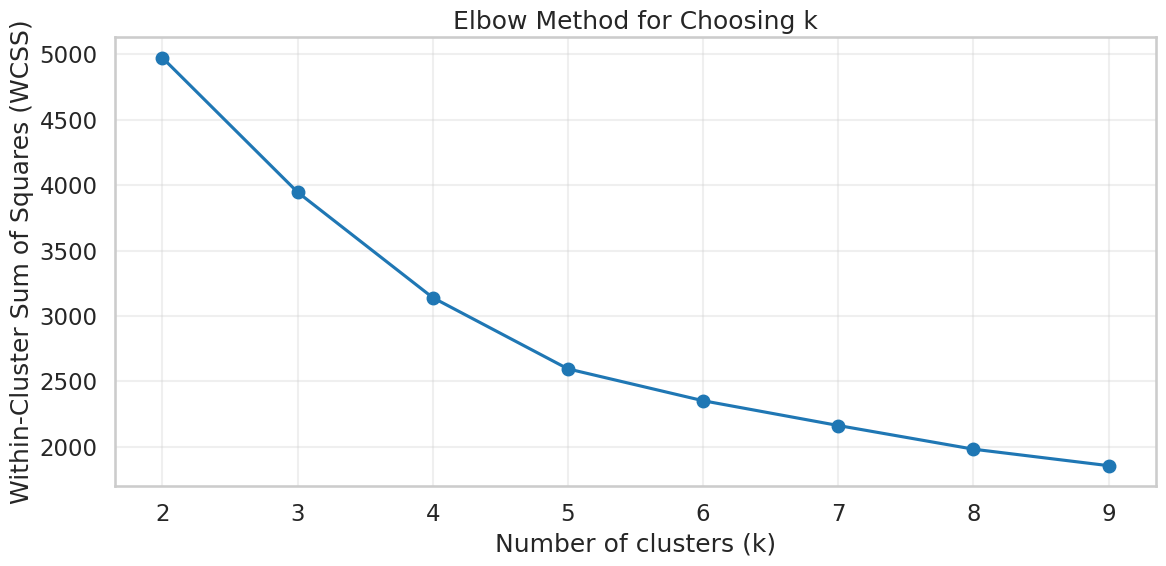

In [140]:
# Compute WCSS (within-cluster sum of squares) for a range of k
wcss = []

K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=25)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plotting elbow curve
plt.figure(figsize=(12, 6))
plt.plot(K_range, wcss, marker="o")
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**1. Observation:**
WCSS declines as (k) increases and begins to flatten around **k = 4**, indicating diminishing returns from adding more clusters.

**2. Business Interpretation:**
This suggests the medicine space can be reasonably described by about **four structural regimes** rather than a large number of fragmented groups.

**3. Implication for Modeling:**
The elbow pattern, combined with silhouette evidence, supports adopting **k = 4** as the primary clustering solution for M2 while avoiding unnecessary complexity.


In [141]:
# Compute Silhouette Scores for KMeans
sil_scores = {}
K_RANGE = range(2, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

sil_scores

{2: np.float64(0.21805325378951457),
 3: np.float64(0.25238078037045825),
 4: np.float64(0.27255178216568005),
 5: np.float64(0.26562350443564064),
 6: np.float64(0.24755573368438),
 7: np.float64(0.2307440237685025),
 8: np.float64(0.24959866354953228),
 9: np.float64(0.2381136736909088)}

**1. Observation:**
Silhouette scores reach their highest point around **k = 4** and then decline gradually rather than showing a sharp peak.

**2. Business Interpretation:**
The moderate (not perfect) scores suggest the regulatory landscape is continuous and messy — full separability is unrealistic in real-world regulatory data.

**3. Implication for Modeling:**
Taken together with the elbow plot, this provides quantitative support for using **k = 4** as the primary clustering solution in M2 while still acknowledging inherent overlap among medicines.


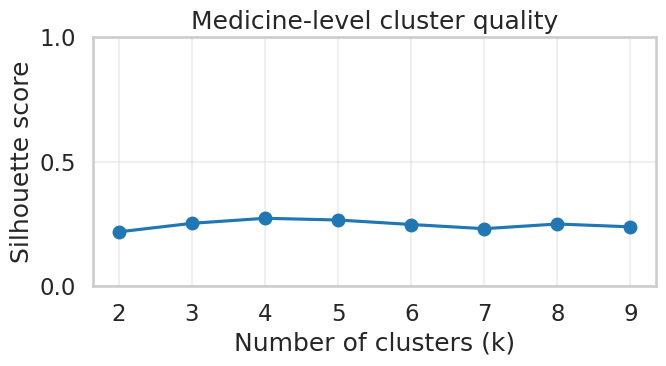

In [142]:
# Plot Silhouette Scores vs. Number of Clusters
plt.figure(figsize=(7,4))

plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")

plt.xticks(list(K_RANGE))
plt.yticks(np.arange(0, 1.01, 0.5))

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Medicine-level cluster quality")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**1. Observation:**
Silhouette scores increase up to about **k = 4** and then flatten or decline as more clusters are added.

**2. Business Interpretation:**
This suggests the medicine space has **moderate latent structure** — there are meaningful groupings, but boundaries between regulatory archetypes are not perfectly sharp.

**3. Implication for Modeling:**
Because separation improves little beyond four clusters while complexity rises, **k = 4** is a defensible primary choice for M2 when considered alongside the elbow plot and interpretability.


In [143]:
# Fit Final KMeans Models for Selected k=4
K = 4

km = KMeans(n_clusters=K, random_state=42, n_init=25)
drug_profile["cluster_k4"] = km.fit_predict(X_scaled)

models = {"k4": km}

# Quick check
drug_profile[["Medicine name", "cluster_k4"]].head()


,Medicine name,cluster_k4
0,Adcetris,0
1,Nityr,1
2,Ebvallo,1
3,Ronapreve,1
4,Cosentyx,0


In [144]:
#PCA projection (single PCA for interpretability)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

drug_profile["pc1_2d"] = X_pca2[:, 0]
drug_profile["pc2_2d"] = X_pca2[:, 1]

pd.Series(pca2.explained_variance_ratio_, index=["PC1", "PC2"]).round(3)

,0
PC1,0.393
PC2,0.235


**1. Observation:**
The 2D PCA compresses the standardized feature space into two axes (PC1 and PC2) that capture the largest sources of variation among medicines.

**2. Business Interpretation:**
PC1 broadly reflects **regulatory friction and pathway intensity** (e.g., revisions and special pathways), while PC2 captures secondary contrasts such as **timing or indication complexity**, consistent with multiple partially independent regulatory processes.

**3. Implication for Modeling:**
The projection is used **for visualization and interpretability only** — it does not determine clusters, but helps verify whether cluster boundaries align with the main dimensions of variation in the data.

In [145]:
#Cluster summary tables (interpretability)
summary_k4 = (
    drug_profile
    .groupby("cluster_k4")
    .agg(
        n_medicines=("Medicine name", "count"),
        mean_revisions=("revision_count", "mean"),
        mean_text_complexity=("text_complexity", "mean"),
        orphan_rate=("Orphan medicine", "mean"),
        mean_decision_year=("decision_year", "mean"),
        am_rate=("am_assigned", "mean"),).round(3).sort_index())

print("Cluster Summary (k=4)")
display(summary_k4)

Cluster Summary (k=4)


,n_medicines,mean_revisions,mean_text_complexity,orphan_rate,mean_decision_year,am_rate
cluster_k4,,,,,,
0,365,30.630,531.696,0.0,2021.956,0.0
1,729,10.040,385.621,0.0,2022.075,0.0
2,416,9.724,360.000,0.0,2020.502,0.0
3,63,21.857,3249.984,0.0,2022.048,0.0


**1. Observation:**
Each row summarizes a cluster in terms of size, average revisions, text complexity, orphan share, decision timing, and AM rate.

**2. Business Interpretation:**
If one or two clusters combine **higher revisions, higher orphan rates, and higher AM rates**, they represent a distinct **“high-uncertainty” regulatory regime**, while other clusters reflect more conventional approval profiles.

**3. Implication for Modeling:**
Clusters with **low AM but similar structural features to high-AM clusters** are especially informative, as they point to potential inconsistencies in how Additional Monitoring is applied.

In [146]:
cluster_col = "cluster_k4"

# Fit 3D PCA
pca3 = PCA(n_components=3, random_state=42)
components = pca3.fit_transform(X_scaled)

# Store components (optional, but keeps consistency with your notebook)
drug_profile["pc1_3d"] = components[:, 0]
drug_profile["pc2_3d"] = components[:, 1]
drug_profile["pc3_3d"] = components[:, 2]

# Total variance explained
total_var = pca3.explained_variance_ratio_.sum() * 100

# Axis labels
labels = {"x": "PC 1", "y": "PC 2", "z": "PC 3"}

# Create interactive plot
fig = px.scatter_3d(
    x=components[:, 0],
    y=components[:, 1],
    z=components[:, 2],
    color=drug_profile[cluster_col].astype(str),
    title=f"Total Explained Variance: {total_var:.2f}%",
    labels=labels)

fig.update_layout(
    template="plotly_white",
    scene=dict(
        xaxis=dict(backgroundcolor="rgb(230,230,230)", gridcolor="white", showbackground=True),
        yaxis=dict(backgroundcolor="rgb(230,230,230)", gridcolor="white", showbackground=True),
        zaxis=dict(backgroundcolor="rgb(230,230,230)", gridcolor="white", showbackground=True),),
    margin=dict(l=0, r=0, b=0, t=40))

fig.show()

**1. Observation:**
The 3D PCA plot places the **k = 4** clusters along the first three principal components, which together explain roughly 50–70% of total variance in the features.

**2. Business Interpretation:**
Clear color separation suggests that KMeans has identified distinct **regulatory archetypes**, while areas of overlap reflect expected ambiguity in real-world regulatory data where medicines share multiple characteristics.

**3. Implication for Modeling:**
Borderline medicines located near the edges between high-AM and low-AM regions are analytically important, as they highlight cases where monitoring decisions may be most uncertain or inconsistent.
